# Logistic Regression Baseline Model

This notebook builds our baseline logistic regression model for classifying which social media platform a post belongs to.

## Goals
- load the final train, validation, test splits processed and saved from the create_datasets notebook
- create a baseline logistic regression model using TF-IDF vectors to encode the post's text and additional text statistics such as number of questions, hashtags, URLs, etc
- explicitly exclude non-text fields such as date/time metadata that could be learned in unuseful ways by the model
- evaluate performance


In [1]:
%pip install polars pyarrow pandas matplotlib scikit-learn scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import html
from time import perf_counter

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)

polars.config.Config

## Paths

In [3]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "train_210k.parquet"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "val_45k.parquet"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "test_45k.parquet"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(TRAIN_PATH, TRAIN_PATH.exists())
print(VAL_PATH, VAL_PATH.exists())
print(TEST_PATH, TEST_PATH.exists())

/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/train_210k.parquet True
/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/val_45k.parquet True
/home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/data/processed/final_dataset_local_duckdb/test_45k.parquet True


## Load train, validation, test data

In [4]:
train_df = pl.read_parquet(TRAIN_PATH)
val_df = pl.read_parquet(VAL_PATH)
test_df = pl.read_parquet(TEST_PATH)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(209987, 18) (44997, 18) (44998, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],f64,f64,…,i8,str,f64,str,f64,f64,str
"""hackernews""","""34593357""","""TheCowboy""","""The idea that tendencies for e…",2023-01-31 05:07:08,null,null,…,1,"""2023-01""",0.0,null,null,null,"""34592394"""
"""hackernews""","""45704131""","""senordevnyc""","""The actual quote is “make some…",2025-10-25 10:21:45,null,null,…,10,"""2025-10""",0.0,null,null,null,"""45704110"""
"""hackernews""","""41076936""","""enriquto""","""> the way it was made callable…",2024-07-26 04:48:48,null,null,…,7,"""2024-07""",0.0,null,null,null,"""41074451"""
"""reddit""","""t3_1fzrjm3""","""sanaloyuncu""","""Hangisini izlemeliyim? Edebiya…",2024-10-09 00:00:00,null,null,…,10,"""2024-10""",1.0,"""liseliler""",1.0,1.0,null
"""hackernews""","""47058341""","""robinwhg""","""But there already is cheaper c…",2026-02-18 02:40:55,null,null,…,2,"""2026-02""",0.0,null,null,null,"""47056458"""


## Quick class balance checks 

In [5]:
print(train_df.group_by("platform").len().sort("platform"))
print(val_df.group_by("platform").len().sort("platform"))
print(test_df.group_by("platform").len().sort("platform"))

shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 69988 │
│ reddit     ┆ 69999 │
│ twitter    ┆ 70000 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 14997 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 14998 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘


## Feature policy

We keep only the text-derived features for the baseline model.

We explicitly do not use features like 
- created_at, year, month, year_month, post_id, author
- platform-specific metadata such as community, likes, retweets, replies, quotes, score, parent_id
because they might encode details about the platform instead of determining it from the language of the post itself

## Add text statistics

In [6]:
def add_text_stats(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col("text").str.count_matches(r"\?").alias("num_questions"),
        pl.col("text").str.count_matches(r"!").alias("num_exclamations"),
        pl.col("text").str.count_matches(r"#\w+").alias("num_hashtags"),
        pl.col("text").str.count_matches(r"@\w+").alias("num_mentions"),
        pl.col("text").str.count_matches(r"http[s]?://").alias("num_urls"),
        pl.col("text").str.count_matches(r"\d").alias("num_digits"),
        pl.col("text").str.count_matches(r"\b[A-Z]{2,}\b").alias("num_allcaps_words"),
        pl.col("text").str.count_matches(r"\b\w+\b").alias("num_words"),
    ]).with_columns([
        (
            pl.col("text_len") /
            pl.when(pl.col("num_words") > 0).then(pl.col("num_words")).otherwise(1)
        ).alias("avg_word_len"),
    ])

train_df = add_text_stats(train_df)
val_df = add_text_stats(val_df)
test_df = add_text_stats(test_df)

train_df.head()

platform,post_id,author,text,created_at,likes,retweets,…,num_hashtags,num_mentions,num_urls,num_digits,num_allcaps_words,num_words,avg_word_len
str,str,str,str,datetime[μs],f64,f64,…,u32,u32,u32,u32,u32,u32,f64
"""hackernews""","""34593357""","""TheCowboy""","""The idea that tendencies for e…",2023-01-31 05:07:08,null,null,…,0,0,0,0,0,49,5.918367
"""hackernews""","""45704131""","""senordevnyc""","""The actual quote is “make some…",2025-10-25 10:21:45,null,null,…,0,0,0,0,0,13,5.923077
"""hackernews""","""41076936""","""enriquto""","""> the way it was made callable…",2024-07-26 04:48:48,null,null,…,0,0,1,3,0,122,5.672131
"""reddit""","""t3_1fzrjm3""","""sanaloyuncu""","""Hangisini izlemeliyim? Edebiya…",2024-10-09 00:00:00,null,null,…,0,0,0,2,0,35,7.4
"""hackernews""","""47058341""","""robinwhg""","""But there already is cheaper c…",2026-02-18 02:40:55,null,null,…,0,0,0,1,0,19,5.947368


## Change to pandas for scikit-learn

In [7]:
train_pdf = train_df.to_pandas()
val_pdf = val_df.to_pandas()
test_pdf = test_df.to_pandas()

print(train_pdf.columns.tolist())

['platform', 'post_id', 'author', 'text', 'created_at', 'likes', 'retweets', 'replies', 'quotes', 'text_len', 'year', 'month', 'year_month', 'score', 'community', 'num_comments', 'upvote_ratio', 'parent_id', 'num_questions', 'num_exclamations', 'num_hashtags', 'num_mentions', 'num_urls', 'num_digits', 'num_allcaps_words', 'num_words', 'avg_word_len']


## Text statistics feature list

In [8]:
TEXT_STAT_COLS = [
    "text_len",
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "num_digits",
    "num_allcaps_words",
    "num_words",
    "avg_word_len",
]

## Build TF-IDF and numeric feature matrices

Here we build use TF-IDF to encode the text of the posts using 1-grams and 2-grams


In [9]:
X_train_text = train_pdf["text"].astype(str)
X_val_text = val_pdf["text"].astype(str)
X_test_text = test_pdf["text"].astype(str)

X_train_num = train_pdf[TEXT_STAT_COLS].astype(float)
X_val_num = val_pdf[TEXT_STAT_COLS].astype(float)
X_test_num = test_pdf[TEXT_STAT_COLS].astype(float)

y_train = train_pdf["platform"]
y_val = val_pdf["platform"]
y_test = test_pdf["platform"]

print("Fitting TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=20000,
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 2),
    stop_words="english",
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF shapes:", X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

scaler = StandardScaler(with_mean=False)

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled = scaler.transform(X_val_num)
X_test_num_scaled = scaler.transform(X_test_num)

X_train_num_sparse = csr_matrix(X_train_num_scaled)
X_val_num_sparse = csr_matrix(X_val_num_scaled)
X_test_num_sparse = csr_matrix(X_test_num_scaled)

X_train_final = hstack([X_train_tfidf, X_train_num_sparse]).tocsr()
X_val_final = hstack([X_val_tfidf, X_val_num_sparse]).tocsr()
X_test_final = hstack([X_test_tfidf, X_test_num_sparse]).tocsr()

print("Final feature shapes:", X_train_final.shape, X_val_final.shape, X_test_final.shape)

Fitting TF-IDF...
TF-IDF shapes: (209987, 20000) (44997, 20000) (44998, 20000)
Final feature shapes: (209987, 20010) (44997, 20010) (44998, 20010)


## Train logistic regression and evaluate

In [10]:
t0 = perf_counter()

baseline_model = LogisticRegression(
    max_iter=5000,
    solver="saga",
    random_state=42,
)

baseline_model.fit(X_train_final, y_train)

t1 = perf_counter()
print(f"Finished training in {t1 - t0:.2f} seconds")
print("Iterations:", baseline_model.n_iter_)

val_pred = baseline_model.predict(X_val_final)
val_accuracy = accuracy_score(y_val, val_pred)

print("\nValidation accuracy:", val_accuracy)
print(classification_report(y_val, val_pred))

test_pred = baseline_model.predict(X_test_final)
test_accuracy = accuracy_score(y_test, test_pred)

print("\nTest accuracy:", test_accuracy)
print(classification_report(y_test, test_pred))

Finished training in 403.42 seconds
Iterations: [2838]

Validation accuracy: 0.8803475787274707
              precision    recall  f1-score   support

  hackernews       0.87      0.87      0.87     14997
      reddit       0.81      0.88      0.85     15000
     twitter       0.97      0.89      0.93     15000

    accuracy                           0.88     44997
   macro avg       0.88      0.88      0.88     44997
weighted avg       0.88      0.88      0.88     44997


Test accuracy: 0.8821503177919019
              precision    recall  f1-score   support

  hackernews       0.87      0.88      0.87     14998
      reddit       0.82      0.88      0.85     15000
     twitter       0.97      0.89      0.93     15000

    accuracy                           0.88     44998
   macro avg       0.89      0.88      0.88     44998
weighted avg       0.89      0.88      0.88     44998



## Confusion matrix on the test set

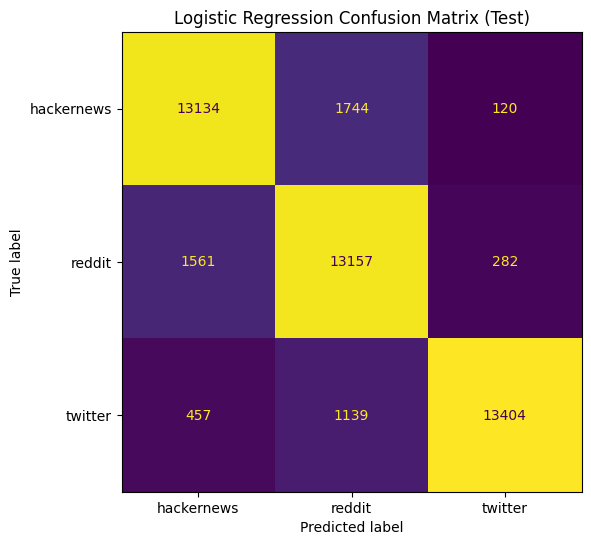

In [11]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, test_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("Logistic Regression Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "logreg_confusion_matrix.png", dpi=150)
plt.show()

## Compare TF-IDF only vs TF-IDF + text statistics

In [12]:
tfidf_only_model = LogisticRegression(
    max_iter=5000,
    solver="saga",
    random_state=42,
)

tfidf_only_model.fit(X_train_tfidf, y_train)
val_pred_tfidf_only = tfidf_only_model.predict(X_val_tfidf)

comparison_df = pd.DataFrame({
    "model": ["TF-IDF only", "TF-IDF and text stats"],
    "validation_accuracy": [
        accuracy_score(y_val, val_pred_tfidf_only),
        val_accuracy,
    ],
})

comparison_df

,model,validation_accuracy
0,TF-IDF only,0.826944
1,TF-IDF and text stats,0.880348


## Look at the most informative features for each class

In [13]:
tfidf_vocab = tfidf.get_feature_names_out()
numeric_names = np.array(TEXT_STAT_COLS)
all_feature_names = np.concatenate([tfidf_vocab, numeric_names])

coef_df = pd.DataFrame(
    baseline_model.coef_.T,
    index=all_feature_names,
    columns=baseline_model.classes_,
)

In [14]:
top_n = 15
for cls in baseline_model.classes_:
    print(f"\n===== Top positive features for {cls} =====")
    print(coef_df[cls].sort_values(ascending=False).head(top_n))


===== Top positive features for hackernews =====
com            6.144383
org            5.272830
hn             3.612377
article        3.476421
www            3.047259
github         3.036329
probably       3.008279
point          2.873561
google         2.724110
people         2.644968
yeah           2.588915
doesn          2.587972
archive        2.558753
interesting    2.521736
example        2.504507
Name: hackernews, dtype: float64

===== Top positive features for reddit =====
telegram     3.307033
looking      2.966019
help         2.583684
overview     2.576608
com          2.486916
guys         2.403684
girl         2.349348
wondering    2.327829
sub          2.150148
dm           2.105480
poll         2.096680
num_words    2.075734
reddit       2.075265
wanna        2.047578
cum          2.042617
Name: reddit, dtype: float64

===== Top positive features for twitter =====
https           15.578726
http             6.958368
num_mentions     2.806335
00               2.341868
l

In [ ]:
# Export logistic regression metrics for the dashboard
import json

LOGREG_OUTPUT_DIR = MODEL_OUTPUT_DIR / "logistic_regression"
LOGREG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logreg_metrics = {·
    "model": "Logistic Regression (TF-IDF + text stats)",
    "validation_accuracy": float(val_accuracy),
    "test_accuracy": float(test_accuracy),
    "macro_f1": float(classification_report(y_test, test_pred, output_dict=True)["macro avg"]["f1-score"]),
    "weighted_f1": float(classification_report(y_test, test_pred, output_dict=True)["weighted avg"]["f1-score"]),
    "classes": [str(label) for label in labels],
    "classification_report": classification_report(y_test, test_pred, output_dict=True),
}

metrics_path = LOGREG_OUTPUT_DIR / "logreg_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(logreg_metrics, f, indent=2)

print(f"Saved metrics to: {metrics_path}")

Saved metrics to: /home/milo/Work/school/CIS_2450/CIS-2450-Final-Project/outputs/modeling/logistic_regression/logreg_metrics.json
